##**Netflix Movies & TV Shows Data Analysis**
Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data Loading

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Netflix_Movies.csv to Netflix_Movies.csv


In [3]:
df = pd.read_csv("Netflix_Movies.csv")

Data Understanding

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [6]:
df.shape

(8807, 12)

In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Data Cleaning

In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

In [13]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Not Available")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")
df["date_added"] = df["date_added"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

In [14]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


##**Exploratory Data Analysis (EDA)**

In [16]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


## Movies vs TV Shows Analysis

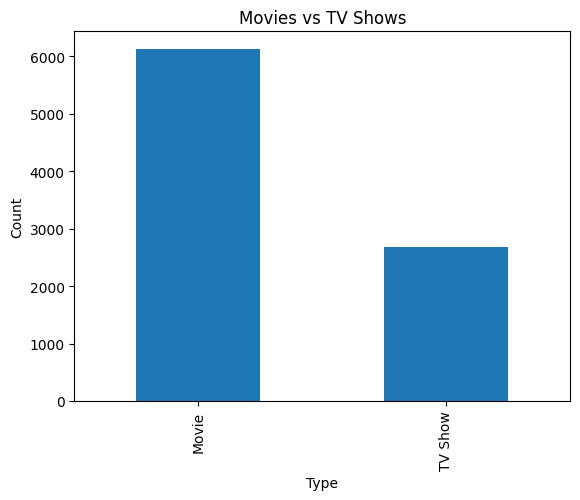

In [17]:
df["type"].value_counts().plot(kind="bar")

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

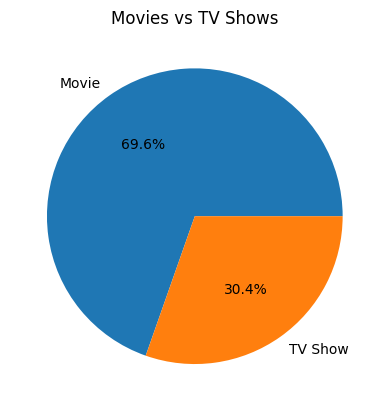

In [18]:
df["type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Movies vs TV Shows")
plt.ylabel("")
plt.show()

## Country-wise Analysis

In [19]:
df["country"].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


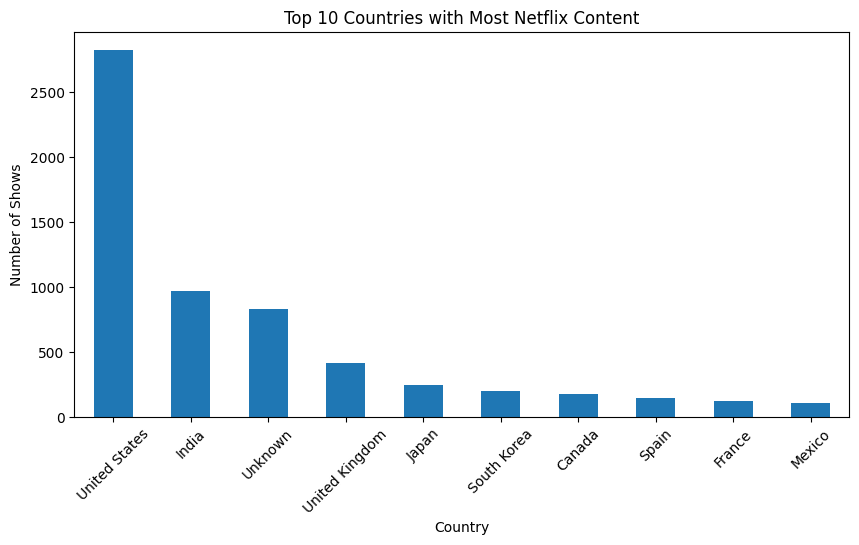

In [20]:
df["country"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries with Most Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)
plt.show()

## Rating Analysis

In [21]:
df["rating"].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


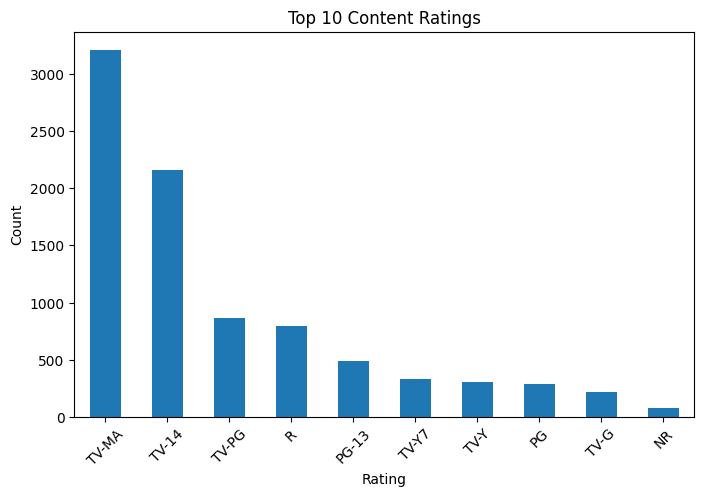

In [22]:
df["rating"].value_counts().head(10).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top 10 Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Release Year Analysis

In [23]:
df["release_year"].value_counts().head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


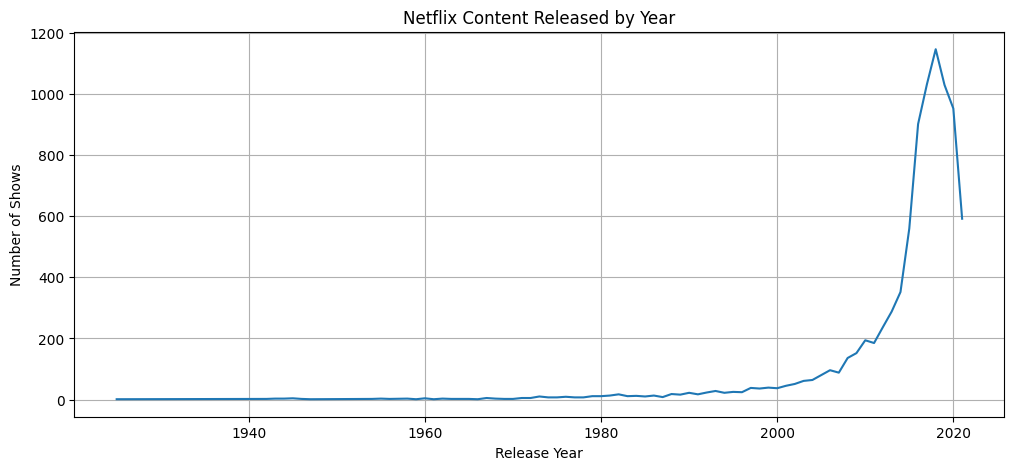

In [24]:
df["release_year"].value_counts().sort_index().plot(
    kind="line",
    figsize=(12,5)
)

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")
plt.grid(True)
plt.show()

## Genre Analysis

In [25]:
df["listed_in"].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


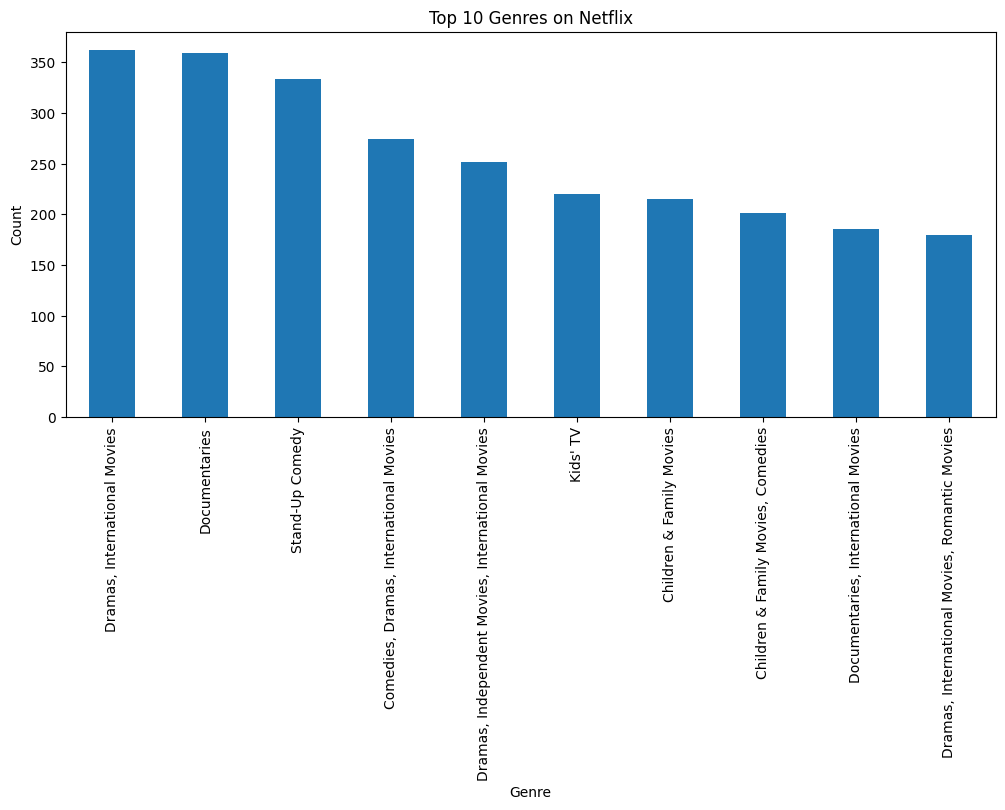

In [26]:
df["listed_in"].value_counts().head(10).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [27]:
df.groupby("type").size()

,0
type,
Movie,6131
TV Show,2676


##**📊 Final Insights**

1. Movies vs TV Shows
Netflix library me Movies (69.6%) ka share TV Shows (30.4%) se kaafi zyada hai.
Ye dikhata hai ki Netflix ka primary content focus Movies par hai.
2. Country-wise Analysis
United States sabse zyada Netflix content produce karta hai.
India second position par hai, jo Netflix ke liye ek important content market hai.
Dataset me Unknown country bhi kaafi records me hai, jo missing country information ko indicate karta hai.
3. Rating Analysis
TV-MA sabse common content rating hai.
Isse pata chalta hai ki Netflix par adult audience ke liye content ki quantity sabse zyada hai.
TV-14 bhi kaafi common rating hai, jo teenagers aur young audience ko target karti hai.
4. Release Year Analysis
2015 ke baad Netflix content me tezi se growth hui.
2019 ke aas-paas content release sabse zyada tha.
2020–2021 me content me thodi kami dikh rahi hai, jo production delays ya dataset update period ki wajah se ho sakti hai.
5. Genre Analysis
International Movies aur Documentaries sabse popular genres me hain.
Stand-Up Comedy bhi top categories me shamil hai.
Isse pata chalta hai ki Netflix alag-alag audience ke liye diverse content provide karta hai.